| Technological Institute of the Philippines | Quezon City - Computer Engineering |
|-------------------------------------------|------------------------------------|
| **Course Code:** | CPE 027 |
| **Code Title:** | Digital Signal Processing and Applications |
| **1st Semester** | AY 2026-2027 |
| **Seatwork No. 3** | **Statistics, Probability, and Noise** |
| **Name:** | Group 6 (Pascual, Lim, Bueno, Jimenez, Carag, Deniega) |
| **Section:** | CPE41S2 |
| **Date Performed:** | 22 July 2026 |
| **Date Submitted:** | 22 July 2026 |
| **Instructor:** | Engr. Jimlord M. Quejado |

With the given data of measured voltage with respect to time, please perform the following:

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

#Load the data
df = pd.read_excel('VoltagevsTime.xlsx')
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Shape: (5001, 2)
Columns: ['Time (sec)', 'Amplitude (V)']


,Time (sec),Amplitude (V)
0,0,221
1,1,213
2,2,252
3,3,212
4,4,260


1. What is the average value for voltage? What is the average and standard deviation?

In [21]:
#Average and Standard Deviation of Voltage
voltage = df['Amplitude (V)']

avg_voltage = voltage.mean()
std_voltage = voltage.std()

print(f"Average Voltage: {avg_voltage:.4f} V")
print(f"Standard Deviation: {std_voltage:.4f} V")

Average Voltage: 219.9264 V
Standard Deviation: 26.1306 V


In [22]:
df.describe()

,Time (sec),Amplitude (V)
count,5001.000000,5001.000000
mean,2500.000000,219.926415
std,1443.808678,26.130568
min,0.000000,117.000000
25%,1250.000000,202.000000
50%,2500.000000,219.000000
75%,3750.000000,236.000000
max,5000.000000,320.000000


2. Plot the values of voltage with respect to time. What do you observe?


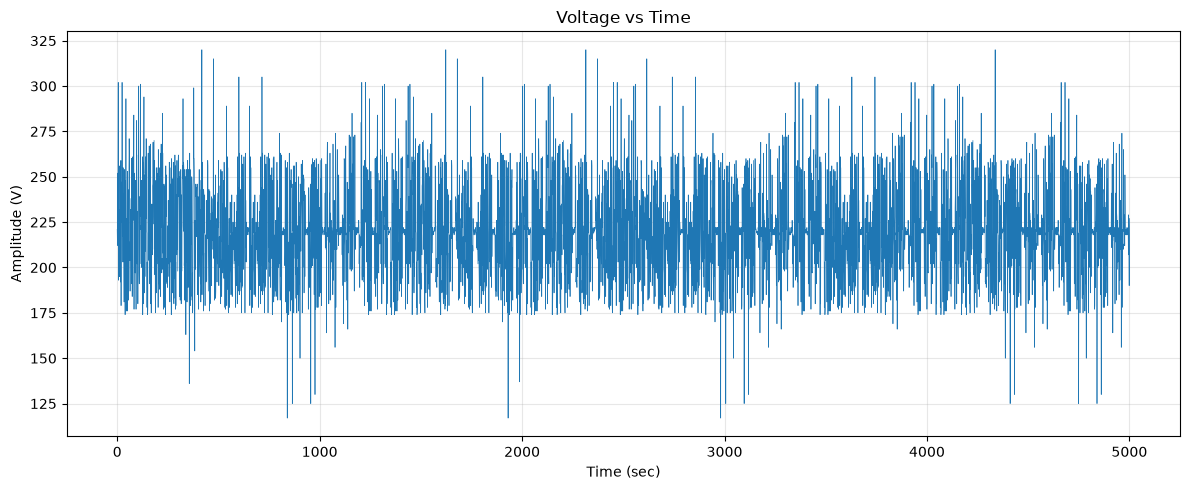

In [23]:
#Plot Voltage vs Time
plt.figure(figsize=(12, 5))
plt.plot(df['Time (sec)'], df['Amplitude (V)'], linewidth=0.5)
plt.xlabel('Time (sec)')
plt.ylabel('Amplitude (V)')
plt.title('Voltage vs Time')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Observations:**
- The voltage fluctuates around an average of 219.93 V throughout the 5,000-second measurement period, with a standard deviation of 26.13 V, indicating moderate variability. However, there are several outliers based on the graph.

3. What is the probability of voltage to have 220 V?


In [24]:
#Probability of Voltage = 220 V
count_220 = (voltage == 220).sum()
total_samples = len(voltage)
prob_220 = count_220 / total_samples

print(f"Count of samples with 220 V: {count_220}")
print(f"Total samples: {total_samples}")
print(f"Probability of voltage = 220 V: {prob_220:.6f} ({prob_220*100:.4f}%)")

Count of samples with 220 V: 177
Total samples: 5001
Probability of voltage = 220 V: 0.035393 (3.5393%)


4. Aside from the average value, find the other central tendency values.


In [25]:
#Other Central Tendency Values (Median and Mode)
median_voltage = voltage.median()
mode_voltage = voltage.mode()[0]

print(f"Mean: {avg_voltage:.4f} V")
print(f"Median: {median_voltage:.4f} V")
print(f"Mode: {mode_voltage:.4f} V")

Mean: 219.9264 V
Median: 219.0000 V
Mode: 222.0000 V


5. Plot the histogram for the first 500 samples, then 1000 samples, then 2000 samples, then 5000 samples. What do you observe?


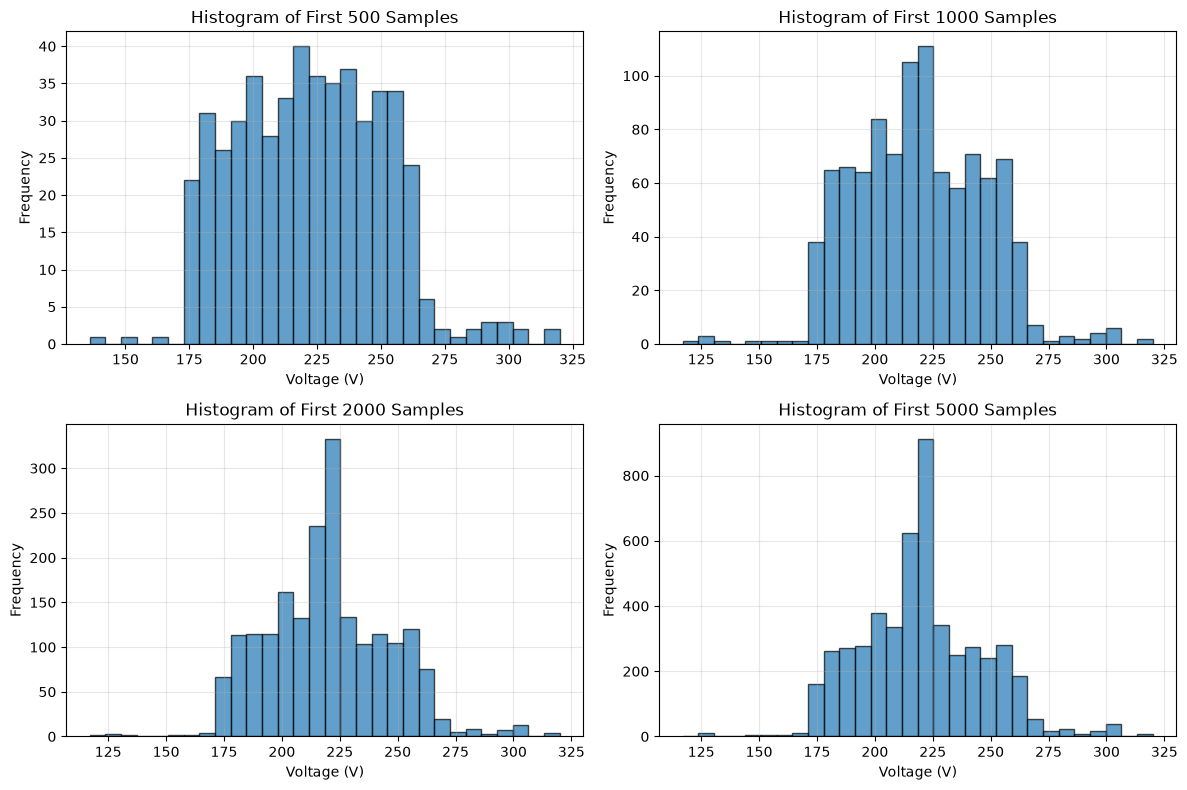

In [26]:
#Histograms for different sample sizes
sample_sizes = [500, 1000, 2000, 5000]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, size in enumerate(sample_sizes):
    axes[i].hist(voltage[:size], bins=30, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Histogram of First {size} Samples')
    axes[i].set_xlabel('Voltage (V)')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Observations:**

- As the sample size increases from 500 to 5,000, the voltage distribution becomes more uneven, highlighting the distribution of the values towards the mean. 

- Across all graphs, the measurements consistently cluster around a central operational range of 220V to 225V.

- Larger datasets capture rare extreme events more effectively, making low-frequency readings below 175V and above 275V clearly visible in the tail ends.


6. What can you conclude on these graphs?

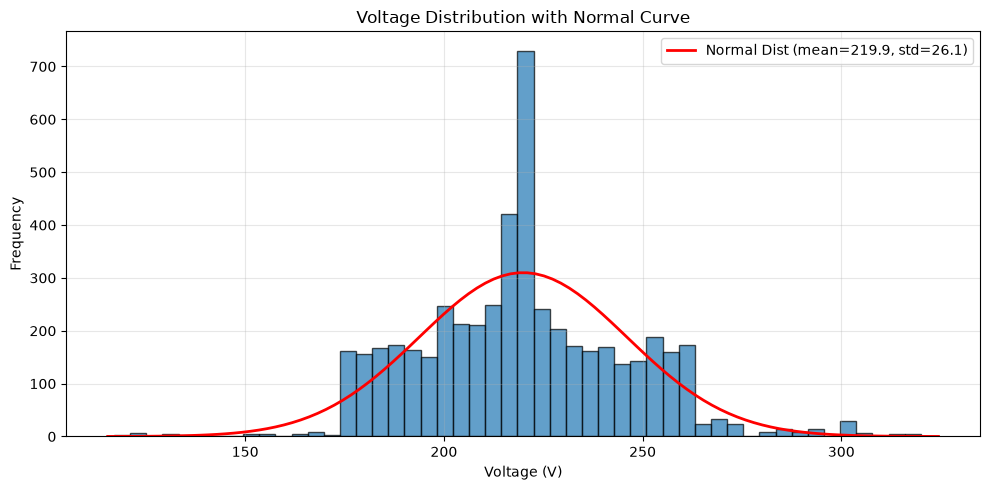

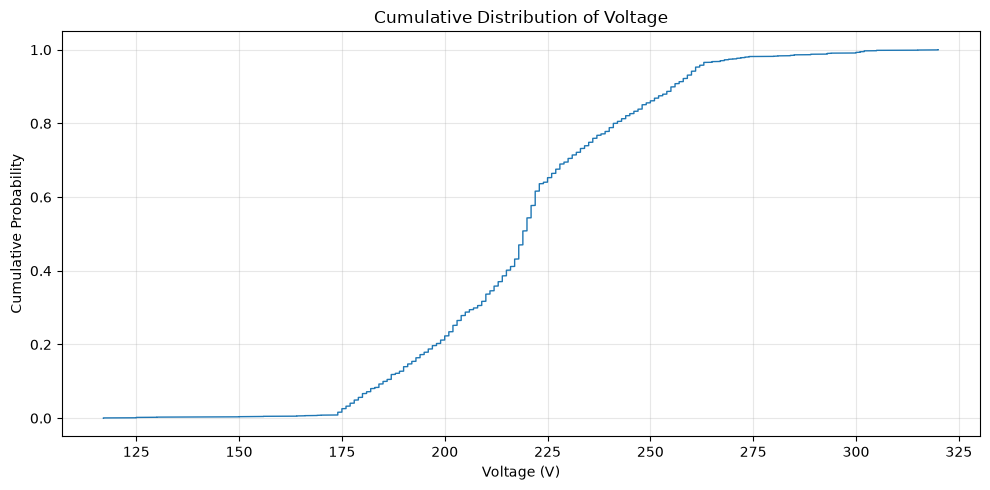

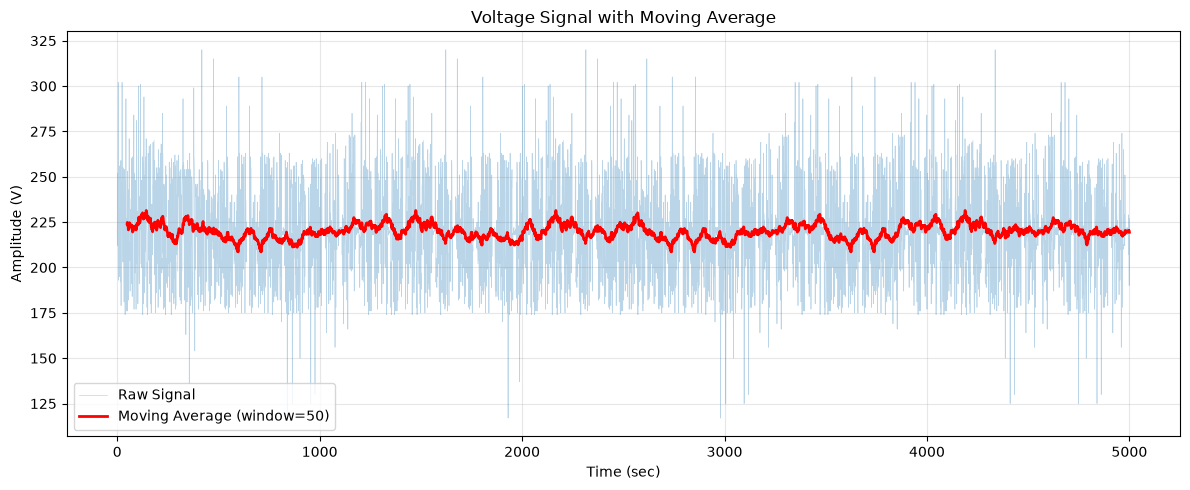

In [27]:
# Visualization 2: Voltage distribution with normal curve overlay
plt.figure(figsize=(10, 5))
count, bins, ignored = plt.hist(voltage, bins=50, alpha=0.7, edgecolor='black')
mu, sigma = avg_voltage, std_voltage
bin_width = bins[1] - bins[0]
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 100)
plt.plot(x, stats.norm.pdf(x, mu, sigma) * len(voltage) * bin_width, 'r-', linewidth=2, label='Normal Dist (mean=' + f'{mu:.1f}' + ', std=' + f'{sigma:.1f}' + ')')
plt.xlabel('Voltage (V)')
plt.ylabel('Frequency')
plt.title('Voltage Distribution with Normal Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Visualization 3: Cumulative distribution
plt.figure(figsize=(10, 5))
sorted_voltage = np.sort(voltage)
cdf = np.arange(1, len(sorted_voltage) + 1) / len(sorted_voltage)
plt.plot(sorted_voltage, cdf, linewidth=1)
plt.xlabel('Voltage (V)')
plt.ylabel('Cumulative Probability')
plt.title('Cumulative Distribution of Voltage')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Visualization 4: Moving average to show trend
window_size = 50 #determines how many consecutive data points are averaged to produce each smoothed value.
moving_avg = voltage.rolling(window=window_size).mean()
plt.figure(figsize=(12, 5))
plt.plot(df['Time (sec)'], df['Amplitude (V)'], alpha=0.3, label='Raw Signal', linewidth=0.5)
plt.plot(df['Time (sec)'], moving_avg, 'r-', label=f'Moving Average (window={window_size})', linewidth=2)
plt.xlabel('Time (sec)')
plt.ylabel('Amplitude (V)')
plt.title('Voltage Signal with Moving Average')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Additional Observations



**Distribution with Normal Curve:**
- The first 5000 samples closely follow the overlaid normal distribution curve (mean of ~219.9 V)
- The voltage measurements are approximately normally distributed.
- The center (around the 225-volt bin) is incredibly higher than normal. 
-  Almost all data was somewhere around 175 - 275 volts only.


**Cumulative Distribution (CDF):**
- The S-shaped curve rises steeply around 200-240 V, which is consistent with the bulk of the data being clustered near the mean. 
- The CDF (Cumulative Dist. Frequency) reaches ~0.5 near 219 V, confirming the median.
- Analyzing the CDF is important in analyzing how clustered the data points are and how volatile or variable the readings are.


**Simple Moving Average:** 
- The moving average highlights the long-term trends amidst the highly volatile / noisy data.
- The raw signal shows high-frequency noise fluctuating around the mean. 
- Moving average (window=50) reveals that the overall trend remains relatively stable over time with no significant upward or downward drift
- The signal is quite stationary and there are no massive fluctuations in each specified window.

PPT: https://canva.link/cl0196sokx8f1xv